# Import

기업 성공확률 예측 모델

In [3]:
%pip install pytorch-tabnet

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold

import torch
from pytorch_tabnet.pretraining import TabNetPretrainer
from pytorch_tabnet.tab_model import TabNetRegressor

Note: you may need to restart the kernel to use updated packages.


| 변수명  | 데이터 타입             |  보간 방법           | 사용 모델                  |
| ---- | ------------------ | ------------------ | ---------------------- |
| 고객수  | 연속형                | 회귀 예측              | RandomForestRegressor  |
| 기업가치 | 연속형  | 전처리 후 회귀 예측        | RandomForestRegressor  |
| 직원 수 | 연속형                | 클러스터링 후 평균 / 회귀 예측 | KMeans + 평균 / RF       |
| 분야   | 범주형                | 분류 예측              | RandomForestClassifier |


# Data Load

In [4]:
#원본 유지
origin_train = pd.read_csv('train.csv')
origin_test = pd.read_csv('test.csv')

In [5]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

# Data Preprocessing

In [7]:
test.tail()

,ID,설립연도,국가,분야,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),기업가치(백억원)
1750,TEST_1750,2015,CT003,에듀테크,Seed,2870.0,Yes,Yes,49.0,539.0,1942.0,4.0,1500-2500
1751,TEST_1751,2006,CT001,핀테크,IPO,278.0,Yes,Yes,35.0,2373.0,10847.0,3.0,4500-6000
1752,TEST_1752,2002,CT001,기술,IPO,1478.0,No,Yes,96.0,4215.0,8297.0,3.0,1500-2500
1753,TEST_1753,2022,CT010,핀테크,IPO,3570.0,No,No,59.0,3333.0,1399.0,5.0,4500-6000
1754,TEST_1754,2016,CT003,게임,Series B,420.0,Yes,No,54.0,80.0,7681.0,1.5,NaN


In [370]:
train.columns

Index(['ID', '설립연도', '국가', '분야', '투자단계', '직원 수', '인수여부', '상장여부', '고객수(백만명)',
       '총 투자금(억원)', '연매출(억원)', 'SNS 팔로워 수(백만명)', '기업가치(백억원)', '성공확률'],
      dtype='object')

In [371]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              4376 non-null   object 
 1   설립연도            4376 non-null   int64  
 2   국가              4376 non-null   object 
 3   분야              3519 non-null   object 
 4   투자단계            4376 non-null   object 
 5   직원 수            4202 non-null   float64
 6   인수여부            4376 non-null   object 
 7   상장여부            4376 non-null   object 
 8   고객수(백만명)        3056 non-null   float64
 9   총 투자금(억원)       4376 non-null   float64
 10  연매출(억원)         4376 non-null   float64
 11  SNS 팔로워 수(백만명)  4376 non-null   float64
 12  기업가치(백억원)       3156 non-null   object 
 13  성공확률            4376 non-null   float64
dtypes: float64(6), int64(1), object(7)
memory usage: 478.8+ KB


In [372]:
train.isna().sum()

ID                   0
설립연도                 0
국가                   0
분야                 857
투자단계                 0
직원 수               174
인수여부                 0
상장여부                 0
고객수(백만명)          1320
총 투자금(억원)            0
연매출(억원)              0
SNS 팔로워 수(백만명)       0
기업가치(백억원)         1220
성공확률                 0
dtype: int64

In [373]:
test.isna().sum()

ID                  0
설립연도                0
국가                  0
분야                354
투자단계                0
직원 수               76
인수여부                0
상장여부                0
고객수(백만명)          547
총 투자금(억원)           0
연매출(억원)             0
SNS 팔로워 수(백만명)      0
기업가치(백억원)         487
dtype: int64

- 결측치 컬럼: 분야(object), 직원수, 고객수, 기업가치(object)

In [374]:
#특성과 타겟 변수 분리
train = train.drop(columns=['ID'], axis = 1)
test = test.drop(columns=['ID'], axis = 1)

In [375]:
# 각 컬럼별 결측치 비율 계산
missing_ratio = train.isnull().mean().sort_values(ascending=False)

# 결측치 비율이 0보다 큰 컬럼만 추출
missing_ratio = missing_ratio[missing_ratio > 0]

# 보기 좋게 %로 표시
missing_ratio_percent = (missing_ratio * 100).round(2)
print(missing_ratio_percent)

고객수(백만명)     30.16
기업가치(백억원)    27.88
분야           19.58
직원 수          3.98
dtype: float64


C:\Users\starf\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


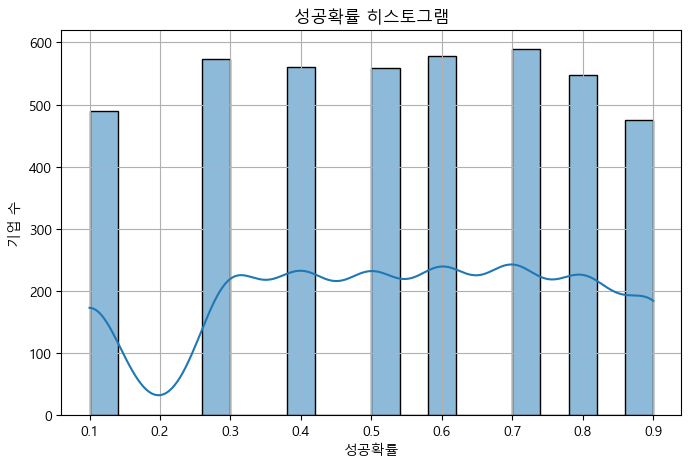

In [376]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 한글 폰트 설정 (Windows의 기본 폰트인 'Malgun Gothic' 사용)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 예시: 한글 포함된 히스토그램
plt.figure(figsize=(8, 5))
sns.histplot(train['성공확률'], bins=20, kde=True)
plt.title('성공확률 히스토그램')
plt.xlabel('성공확률')
plt.ylabel('기업 수')
plt.grid(True)
plt.show()

In [377]:
# 설립연도 타입 변환 (int -> object)
train['설립연도'] =train['설립연도'].astype('object')
test['설립연도'] =test['설립연도'].astype('object')

category_features = ['설립연도','국가','분야','투자단계','기업가치(백억원)'] #범주형
numeric_features = ['직원 수','고객수(백만명)','총 투자금(억원)','연매출(억원)','SNS 팔로워 수(백만명)'] #수치형
bool_features = ['인수여부','상장여부'] 

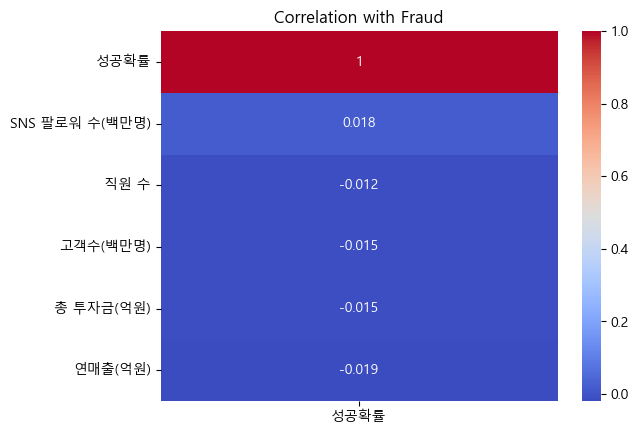

In [378]:
import seaborn as sns
import matplotlib.pyplot as plt

# 수치형 칼럼만 선택
numeric_cols = train.select_dtypes(include=['number'])

# 히트맵
sns.heatmap(numeric_cols.corr()[['성공확률']].sort_values(by='성공확률', ascending=False),
            annot=True, cmap='coolwarm')
plt.title("Correlation with Fraud")
plt.show()

## ANOVA
- 여러 그룹 간의 통계적으로 유의미한 차이를 검정하는 통계적 절차

In [379]:
train.columns

Index(['설립연도', '국가', '분야', '투자단계', '직원 수', '인수여부', '상장여부', '고객수(백만명)',
       '총 투자금(억원)', '연매출(억원)', 'SNS 팔로워 수(백만명)', '기업가치(백억원)', '성공확률'],
      dtype='object')

### 가설 설정 (이진변수를 기준으로 연속형 값의 평균 차이를 비교할 것임)
- 1. 인수여부, 상장여부가 참이면 성공확률은 증가할 것이다.
    - 귀무가설: 인수 여부/상장여부에 따라 성공확률의 평균은 차이가 없다.
    - 대립가설: 인수/상장된 기업이 인수/상장되지 않은 기업보다 평균 성공확률이 높다.

In [380]:
# 불리언 값을 0과 1로 변환 ('Yes' → 1, 'No' → 0 으로 변환)
bool_map = {'Yes': 1, 'No': 0}

for feature in bool_features:
    train[feature] = train[feature].map(bool_map)
    test[feature] = test[feature].map(bool_map)

### 독립표본 t-검정

In [381]:
from scipy.stats import ttest_ind

# 상장 여부에 따라 그룹 나누기
group_listed = train[train['상장여부'] == 1]['성공확률']
group_not_listed = train[train['상장여부'] == 0]['성공확률']

# t-test 수행
t_stat, p_value = ttest_ind(group_listed, group_not_listed, equal_var=False)

print(f"t-statistic: {t_stat}, p-value: {p_value}")

t-statistic: 2.079154933489617, p-value: 0.037661451984323246


In [382]:
# 인수 여부에 따라 그룹 나누기
group_listed = train[train['인수여부'] == 1]['성공확률']
group_not_listed = train[train['인수여부'] == 0]['성공확률']

# t-test 수행
t_stat, p_value = ttest_ind(group_listed, group_not_listed, equal_var=False)

print(f"t-statistic: {t_stat}, p-value: {p_value}")

t-statistic: -0.797801799825947, p-value: 0.4250290406586925


- 상장 여부에 따른 성공확률의 평균 차이가 통계적으로 유의함 (0.05 이하)

### 이원분산분석 (인수여부+상장여부)

In [383]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 두 범주형 변수의 효과를 동시에 분석
model = ols('성공확률 ~ C(인수여부) + C(상장여부) + C(인수여부):C(상장여부)', data=train).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                     sum_sq      df         F    PR(>F)
C(인수여부)            0.033116     1.0  0.567174  0.451425
C(상장여부)            0.248108     1.0  4.249308  0.039325
C(인수여부):C(상장여부)    0.021626     1.0  0.370382  0.542828
Residual         255.271702  4372.0       NaN       NaN


- 상장여부만 성공확률에 유의한 긍정적 영향을 주는 반면,
- 인수여부 자체나 인수+상장의 상호작용은 유의하지 않은 것으로 판명

In [384]:
# 상장 여부에 따른 성공확률 평균 비교
mean_success_by_listing = train.groupby('상장여부')['성공확률'].mean()
print(mean_success_by_listing)

상장여부
0    0.530004
1    0.545196
Name: 성공확률, dtype: float64


- 그러나 실제 차이 크기는 작음. 데이터 수가 적어서 그룹 간 평균 차이가 작아도 유의할 수 있음

### 범주형 변수 시각화

C:\Users\starf\AppData\Local\Temp\ipykernel_12028\1233572920.py:11: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from current font.
  plt.tight_layout()
C:\Users\starf\AppData\Local\Temp\ipykernel_12028\1233572920.py:11: UserWarning: Glyph 45320 (\N{HANGUL SYLLABLE NEO}) missing from current font.
  plt.tight_layout()
C:\Users\starf\AppData\Local\Temp\ipykernel_12028\1233572920.py:11: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
C:\Users\starf\AppData\Local\Temp\ipykernel_12028\1233572920.py:11: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  plt.tight_layout()
C:\Users\starf\AppData\Local\Temp\ipykernel_12028\1233572920.py:11: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from current font.
  plt.tight_layout()
C:\Users\starf\AppData\Local\Temp\ipykernel_12028\1233572920.py:11: UserWarning: Glyph 46272 (\N{HANGUL SYLLABLE DYU}) missing from current font.
  plt.tight_layout()
C:

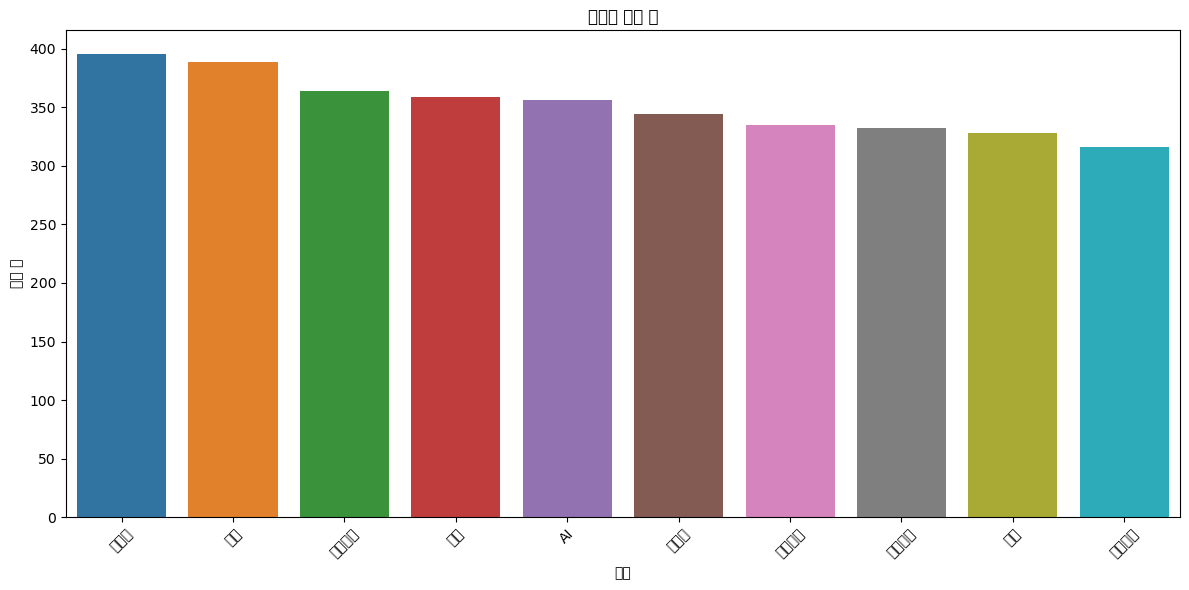

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.countplot(data=train, x='분야', order=train['분야'].value_counts().index)

plt.title('분야별 기업 수')
plt.xlabel('분야')
plt.ylabel('기업 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

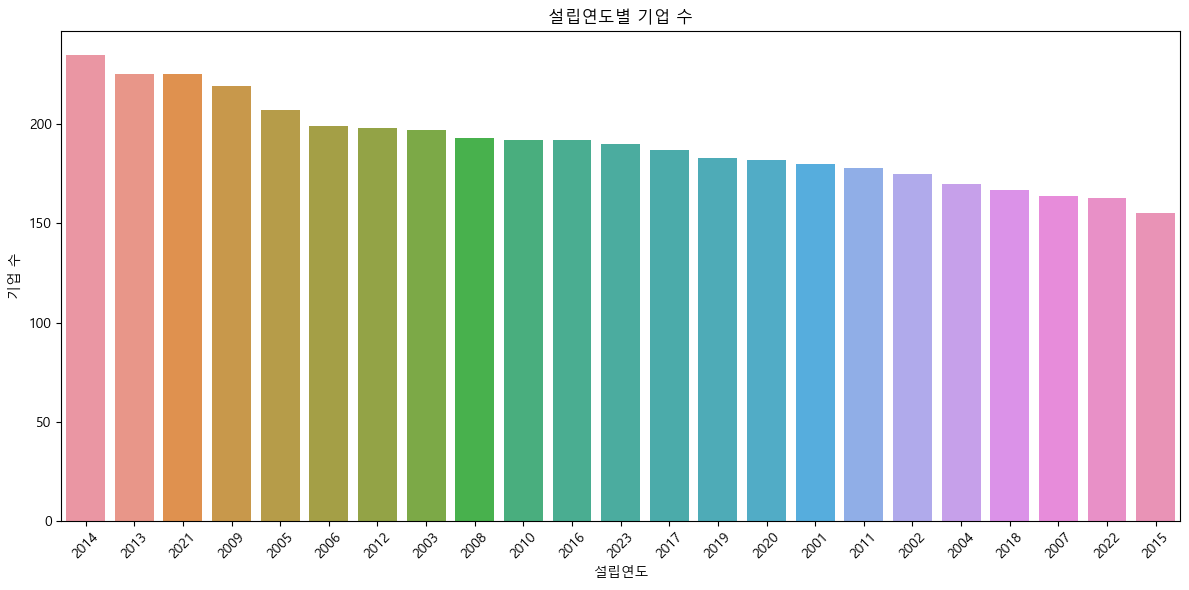

In [386]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.countplot(data=train, x='설립연도', order=train['설립연도'].value_counts().index)

plt.title('설립연도별 기업 수')
plt.xlabel('설립연도')
plt.ylabel('기업 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

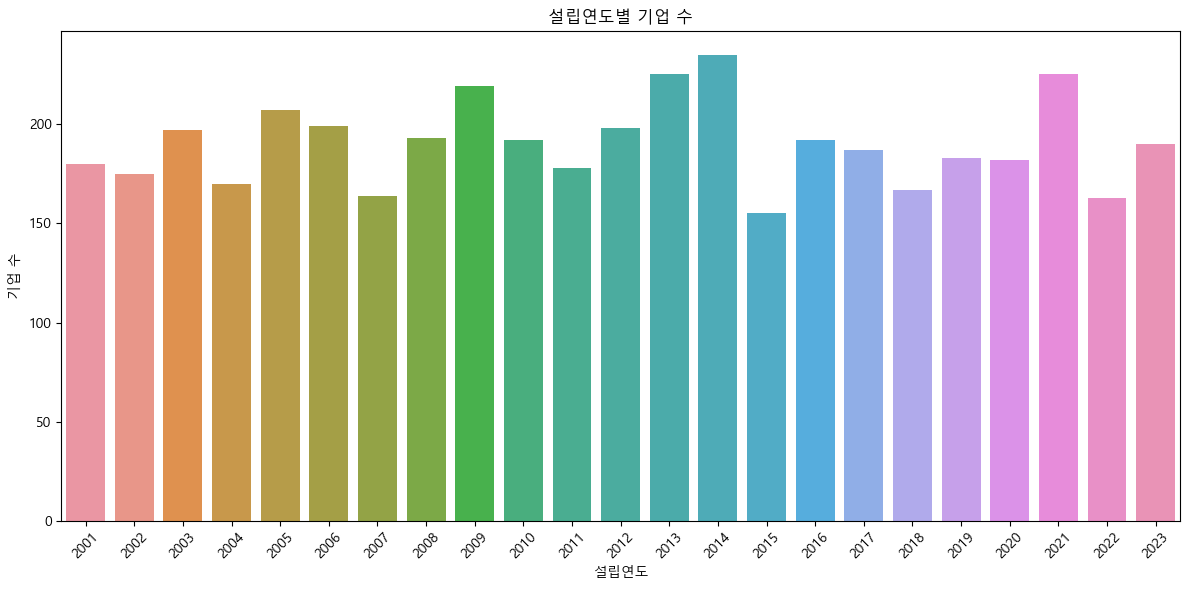

In [387]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train, x='설립연도')

plt.title('설립연도별 기업 수')
plt.xlabel('설립연도')
plt.ylabel('기업 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

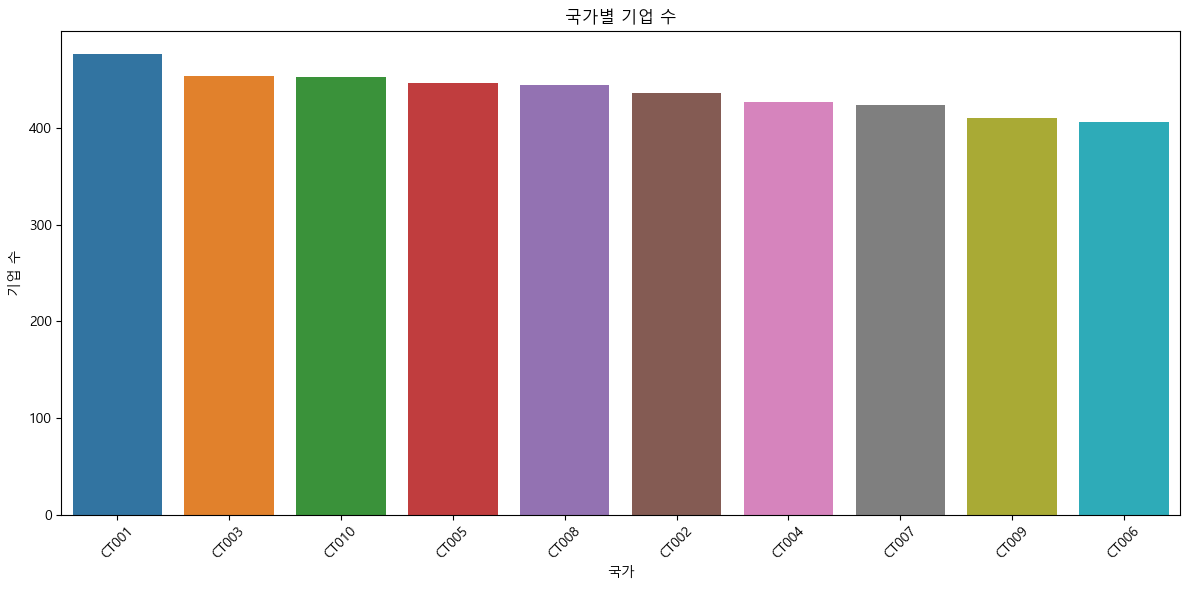

In [388]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train, x='국가', order=train['국가'].value_counts().index)

plt.title('국가별 기업 수')
plt.xlabel('국가')
plt.ylabel('기업 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

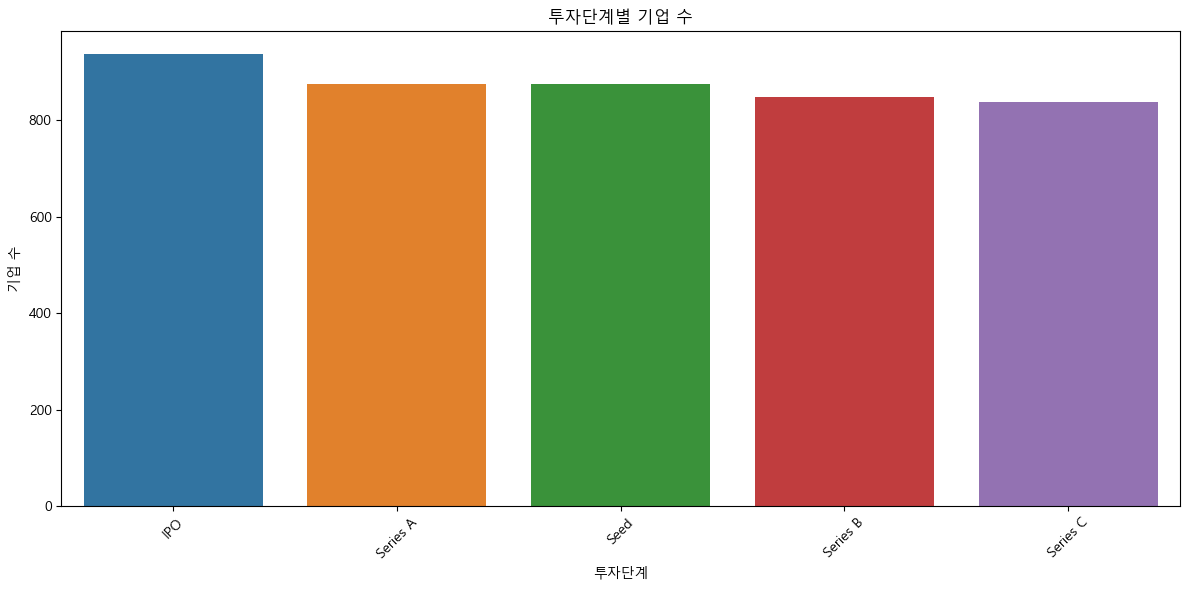

In [389]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train, x='투자단계', order=train['투자단계'].value_counts().index)

plt.title('투자단계별 기업 수')
plt.xlabel('투자단계')
plt.ylabel('기업 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Seed: 아이디어와 초기 제품을 위한 자금.

- Series A: 제품과 시장 검증 후, 성장 확대를 위한 자금.

- Series B: 성장을 지속적으로 확장하고, 더 큰 시장을 목표로 하는 자금.

- IPO: 주식 공개를 통해 자금을 조달하고, 기업을 공개적으로 운영하는 단계.

### 기업가치 처리

- 기업 가치 오브젝트 -> 수치형으로 변환

In [390]:
import pandas as pd

def convert_range_to_mean(value):
    if pd.isna(value):
        return None
    if '-' in value:
        # '2500-3500' → 평균 계산
        start, end = value.split('-')
        return (int(start) + int(end)) / 2
    else:
        # 숫자형 문자열이거나 'Missing' 처리된 값
        try:
            return float(value)
        except:
            return None

# 적용
train['기업가치(백억원)_수치형'] = train['기업가치(백억원)'].apply(convert_range_to_mean)
test['기업가치(백억원)_수치형'] = test['기업가치(백억원)'].apply(convert_range_to_mean)

In [391]:
print(train['기업가치(백억원)_수치형'].dtype)  # float64로 변환되어야 함

float64


In [392]:
train.head()

,설립연도,국가,분야,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),기업가치(백억원),성공확률,기업가치(백억원)_수치형
0,2009,CT005,이커머스,Series A,4126.0,0,0,56.0,3365.0,4764.0,4.71,NaN,0.3,NaN
1,2023,CT006,핀테크,Seed,4167.0,1,0,80.0,4069.0,279.0,1.00,2500-3500,0.8,3000.0
2,2018,CT007,기술,Series A,3132.0,1,1,54.0,6453.0,12141.0,4.00,3500-4500,0.5,4000.0
3,2016,CT006,NaN,Seed,3245.0,1,1,NaN,665.0,10547.0,2.97,NaN,0.7,NaN
4,2020,CT002,에듀테크,Seed,1969.0,0,1,94.0,829.0,9810.0,1.00,1500-2500,0.1,2000.0


In [393]:
# 상관계수 계산 (피어슨 상관계수)
correlation = train[['기업가치(백억원)_수치형', '성공확률']].corr(method='pearson')
print(correlation)

               기업가치(백억원)_수치형      성공확률
기업가치(백억원)_수치형       1.000000  0.009127
성공확률                0.009127  1.000000


In [394]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   설립연도            4376 non-null   object 
 1   국가              4376 non-null   object 
 2   분야              3519 non-null   object 
 3   투자단계            4376 non-null   object 
 4   직원 수            4202 non-null   float64
 5   인수여부            4376 non-null   int64  
 6   상장여부            4376 non-null   int64  
 7   고객수(백만명)        3056 non-null   float64
 8   총 투자금(억원)       4376 non-null   float64
 9   연매출(억원)         4376 non-null   float64
 10  SNS 팔로워 수(백만명)  4376 non-null   float64
 11  기업가치(백억원)       3156 non-null   object 
 12  성공확률            4376 non-null   float64
 13  기업가치(백억원)_수치형   2563 non-null   float64
dtypes: float64(7), int64(2), object(5)
memory usage: 478.8+ KB


# 타입 변환 (int -> object)
train['인수여부'] =train['인수여부'].astype('object')
test['상장여부'] =test['상장여부'].astype('object')

### 회귀

In [395]:
correlation = train[['직원 수', '성공확률']].corr(method='pearson')
print(correlation)

          직원 수      성공확률
직원 수  1.000000 -0.011831
성공확률 -0.011831  1.000000


In [396]:
correlation = train[['고객수(백만명)', '성공확률']].corr(method='pearson')
print(correlation)

          고객수(백만명)      성공확률
고객수(백만명)  1.000000 -0.014746
성공확률     -0.014746  1.000000


In [397]:
correlation = train[['총 투자금(억원)', '성공확률']].corr(method='pearson')
print(correlation)

           총 투자금(억원)      성공확률
총 투자금(억원)   1.000000 -0.014939
성공확률       -0.014939  1.000000


In [398]:
correlation = train[['연매출(억원)', '성공확률']].corr(method='pearson')
print(correlation)

          연매출(억원)      성공확률
연매출(억원)  1.000000 -0.018994
성공확률    -0.018994  1.000000


In [399]:
correlation = train[['SNS 팔로워 수(백만명)', '성공확률']].corr(method='pearson')
print(correlation)

                SNS 팔로워 수(백만명)      성공확률
SNS 팔로워 수(백만명)        1.000000  0.017927
성공확률                  0.017927  1.000000


- 모두 상관계수가 1에 가깝지 않음 (강한 양의 상관관계를 보이지는 않음)
- 비선형회귀 혹은 다중회귀가 필요해보임

In [400]:
import statsmodels.api as sm

# 데이터 준비
X = train['기업가치(백억원)_수치형']
y = train['성공확률']

# 결측치 제거
data = pd.concat([X, y], axis=1).dropna()
X = data['기업가치(백억원)_수치형']
y = data['성공확률']

# 상수항 추가 (절편)
X = sm.add_constant(X)

# 회귀 모델 적합
model = sm.OLS(y, X).fit()

# 결과 출력
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   성공확률   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.2134
Date:                Fri, 23 May 2025   Prob (F-statistic):              0.644
Time:                        21:26:56   Log-Likelihood:                 10.864
No. Observations:                2563   AIC:                            -17.73
Df Residuals:                    2561   BIC:                            -6.031
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.5243      0.015     35.159

### 결측치 보간 처리

In [401]:
train.isna().sum()

설립연도                 0
국가                   0
분야                 857
투자단계                 0
직원 수               174
인수여부                 0
상장여부                 0
고객수(백만명)          1320
총 투자금(억원)            0
연매출(억원)              0
SNS 팔로워 수(백만명)       0
기업가치(백억원)         1220
성공확률                 0
기업가치(백억원)_수치형     1813
dtype: int64

In [402]:
test.isna().sum()

설립연도                0
국가                  0
분야                354
투자단계                0
직원 수               76
인수여부                0
상장여부                0
고객수(백만명)          547
총 투자금(억원)           0
연매출(억원)             0
SNS 팔로워 수(백만명)      0
기업가치(백억원)         487
기업가치(백억원)_수치형     696
dtype: int64

In [403]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   설립연도            4376 non-null   object 
 1   국가              4376 non-null   object 
 2   분야              3519 non-null   object 
 3   투자단계            4376 non-null   object 
 4   직원 수            4202 non-null   float64
 5   인수여부            4376 non-null   int64  
 6   상장여부            4376 non-null   int64  
 7   고객수(백만명)        3056 non-null   float64
 8   총 투자금(억원)       4376 non-null   float64
 9   연매출(억원)         4376 non-null   float64
 10  SNS 팔로워 수(백만명)  4376 non-null   float64
 11  기업가치(백억원)       3156 non-null   object 
 12  성공확률            4376 non-null   float64
 13  기업가치(백억원)_수치형   2563 non-null   float64
dtypes: float64(7), int64(2), object(5)
memory usage: 478.8+ KB


In [404]:
train.head()

,설립연도,국가,분야,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),기업가치(백억원),성공확률,기업가치(백억원)_수치형
0,2009,CT005,이커머스,Series A,4126.0,0,0,56.0,3365.0,4764.0,4.71,NaN,0.3,NaN
1,2023,CT006,핀테크,Seed,4167.0,1,0,80.0,4069.0,279.0,1.00,2500-3500,0.8,3000.0
2,2018,CT007,기술,Series A,3132.0,1,1,54.0,6453.0,12141.0,4.00,3500-4500,0.5,4000.0
3,2016,CT006,NaN,Seed,3245.0,1,1,NaN,665.0,10547.0,2.97,NaN,0.7,NaN
4,2020,CT002,에듀테크,Seed,1969.0,0,1,94.0,829.0,9810.0,1.00,1500-2500,0.1,2000.0


#### 고객수

In [405]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# 2. '설립연도' → 숫자형으로 변환
train['설립연도'] = pd.to_numeric(train['설립연도'], errors='coerce')

# 3. '직원 수' 평균으로 보간
train['직원 수'] = train['직원 수'].fillna(train['직원 수'].mean())

# 4. 결측치가 있는 '고객수' 예측에 사용할 피처만 선택 (분야와 기업가치 제외)
selected_features = [
    '설립연도', '국가', '투자단계', '직원 수', '인수여부', '상장여부',
    '총 투자금(억원)', '연매출(억원)', 'SNS 팔로워 수(백만명)', '성공확률'
]

# 5. 범주형 인코딩: LabelEncoder
label_encoders = {}
for col in ['국가', '투자단계']:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    label_encoders[col] = le

# 6. 학습/예측용 데이터 분리
train_df = train[train['고객수(백만명)'].notnull()]
test_df = train[train['고객수(백만명)'].isnull()]

X_train = train_df[selected_features]
y_train = train_df['고객수(백만명)']
X_pred = test_df[selected_features]

# 7. 혹시 모를 입력 피처 결측값은 평균으로 보완
X_train = X_train.fillna(X_train.mean())
X_pred = X_pred.fillna(X_train.mean())  # 학습 기준으로 맞춤

# 8. 모델 학습 및 예측
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)
preds = model.predict(X_pred)

# 9. 예측값 채우기
train.loc[train['고객수(백만명)'].isnull(), '고객수(백만명)'] = preds

# 10. 결과 확인
print("남은 고객수 결측치 수:", train['고객수(백만명)'].isna().sum())

남은 고객수 결측치 수: 0


In [406]:
train.isna().sum()

설립연도                 0
국가                   0
분야                 857
투자단계                 0
직원 수                 0
인수여부                 0
상장여부                 0
고객수(백만명)             0
총 투자금(억원)            0
연매출(억원)              0
SNS 팔로워 수(백만명)       0
기업가치(백억원)         1220
성공확률                 0
기업가치(백억원)_수치형     1813
dtype: int64

#### 기업가치

In [407]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# 2. 설립연도 숫자형으로 변환
train['설립연도'] = pd.to_numeric(train['설립연도'], errors='coerce')

# 3. 직원 수 평균 보간 (이미 되어있다면 생략 가능)
train['직원 수'] = train['직원 수'].fillna(train['직원 수'].mean())

# 4. 범주형 인코딩 대상: 국가, 투자단계
label_encoders = {}
for col in ['국가', '투자단계']:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    label_encoders[col] = le

# 5. 학습/예측용 피처 정의
features = [
    '설립연도', '국가', '투자단계', '직원 수', '인수여부', '상장여부',
    '고객수(백만명)', '총 투자금(억원)', '연매출(억원)', 'SNS 팔로워 수(백만명)', '성공확률'
]

# 6. 결측치 여부에 따라 분할
df_train = train[train['기업가치(백억원)_수치형'].notnull()]
df_pred  = train[train['기업가치(백억원)_수치형'].isnull()]

X_train = df_train[features]
y_train = df_train['기업가치(백억원)_수치형']
X_pred  = df_pred[features]

# 7. 피처 내 남은 결측치 보완 (설립연도 등에서 있을 수 있음)
X_train = X_train.fillna(X_train.mean())
X_pred = X_pred.fillna(X_train.mean())

# 8. 모델 학습 및 예측
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_pred)

# 9. 예측값 삽입
train.loc[train['기업가치(백억원)_수치형'].isnull(), '기업가치(백억원)_수치형'] = preds

# 10. 확인
print("남은 기업가치(백억원)_수치형 결측치 수:", train['기업가치(백억원)_수치형'].isna().sum())


남은 기업가치(백억원)_수치형 결측치 수: 0


In [408]:
train.isna().sum()

설립연도                 0
국가                   0
분야                 857
투자단계                 0
직원 수                 0
인수여부                 0
상장여부                 0
고객수(백만명)             0
총 투자금(억원)            0
연매출(억원)              0
SNS 팔로워 수(백만명)       0
기업가치(백억원)         1220
성공확률                 0
기업가치(백억원)_수치형        0
dtype: int64

#### 분야

In [409]:
train.head()

,설립연도,국가,분야,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),기업가치(백억원),성공확률,기업가치(백억원)_수치형
0,2009,4,이커머스,2,4126.0,0,0,56.00,3365.0,4764.0,4.71,NaN,0.3,3472.5
1,2023,5,핀테크,1,4167.0,1,0,80.00,4069.0,279.0,1.00,2500-3500,0.8,3000.0
2,2018,6,기술,2,3132.0,1,1,54.00,6453.0,12141.0,4.00,3500-4500,0.5,4000.0
3,2016,5,NaN,1,3245.0,1,1,44.57,665.0,10547.0,2.97,NaN,0.7,3950.0
4,2020,1,에듀테크,1,1969.0,0,1,94.00,829.0,9810.0,1.00,1500-2500,0.1,2000.0


In [410]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 2. '기업가치(백억원)' 제거
train.drop(columns=['기업가치(백억원)'], inplace=True)

# 5. Label Encoding
label_encoders = {}
for col in ['국가', '투자단계', '분야']:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    label_encoders[col] = le

# 6. 결측치 있는지 확인
missing_rows = train[train['분야'] == label_encoders['분야'].transform(['nan'])[0]]

if len(missing_rows) == 0:
    print("결측치가 없습니다. 예측을 생략합니다.")
else:
    # 7. 예측에 사용할 피처
    features = [
        '설립연도', '국가', '투자단계', '직원 수', '인수여부', '상장여부',
        '고객수(백만명)', '총 투자금(억원)', '연매출(억원)',
        'SNS 팔로워 수(백만명)', '기업가치(백억원)_수치형', '성공확률'
    ]

    df_train = train[train['분야'] != label_encoders['분야'].transform(['nan'])[0]]
    df_pred = train[train['분야'] == label_encoders['분야'].transform(['nan'])[0]]

    X_train = df_train[features].copy()
    y_train = df_train['분야'].copy()
    X_pred = df_pred[features].copy()

    # 8. 수치형 결측값 처리 (설립연도 등)
    X_train = X_train.fillna(X_train.mean())
    X_pred = X_pred.fillna(X_train.mean())

    # 9. 모델 훈련 및 예측
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_pred)

    # 10. 예측 결과 반영
    train.loc[train['분야'] == label_encoders['분야'].transform(['nan'])[0], '분야'] = preds

    # 11. 인코딩 복호화 (선택)
    train['분야'] = label_encoders['분야'].inverse_transform(train['분야'].astype(int))

# 12. 확인
print("최종 결측치:\n", train.isnull().sum())


최종 결측치:
 설립연도              0
국가                0
분야                0
투자단계              0
직원 수              0
인수여부              0
상장여부              0
고객수(백만명)          0
총 투자금(억원)         0
연매출(억원)           0
SNS 팔로워 수(백만명)    0
성공확률              0
기업가치(백억원)_수치형     0
dtype: int64


In [411]:
train.head()

,설립연도,국가,분야,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),성공확률,기업가치(백억원)_수치형
0,2009,4,이커머스,2,4126.0,0,0,56.00,3365.0,4764.0,4.71,0.3,3472.5
1,2023,5,핀테크,1,4167.0,1,0,80.00,4069.0,279.0,1.00,0.8,3000.0
2,2018,6,기술,2,3132.0,1,1,54.00,6453.0,12141.0,4.00,0.5,4000.0
3,2016,5,게임,1,3245.0,1,1,44.57,665.0,10547.0,2.97,0.7,3950.0
4,2020,1,에듀테크,1,1969.0,0,1,94.00,829.0,9810.0,1.00,0.1,2000.0


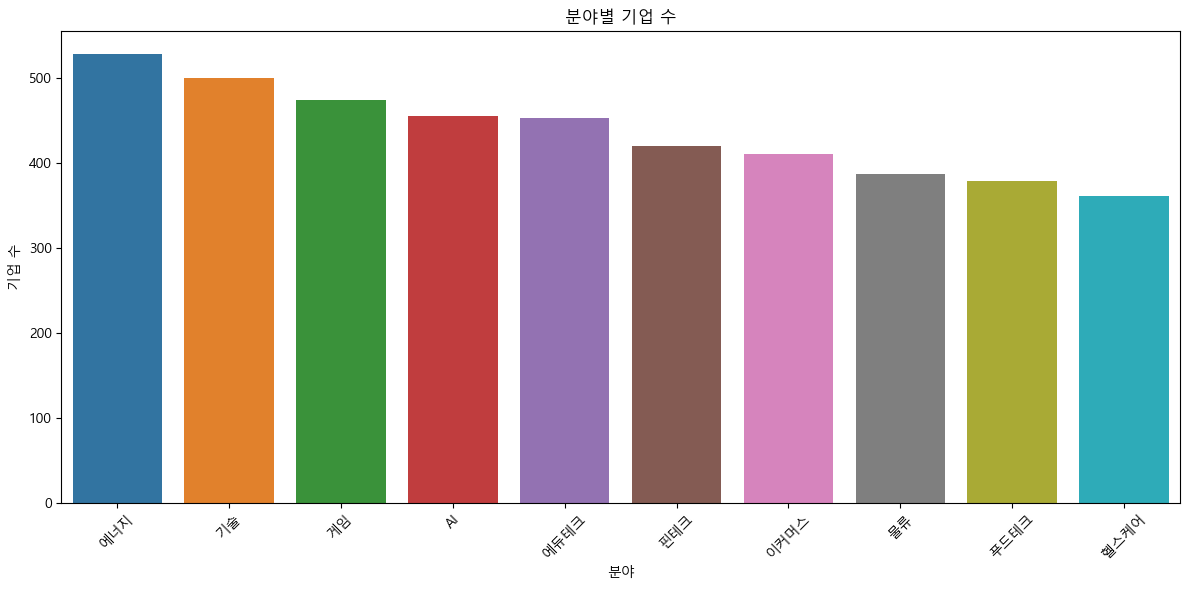

In [412]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.countplot(data=train, x='분야', order=train['분야'].value_counts().index)

plt.title('분야별 기업 수')
plt.xlabel('분야')
plt.ylabel('기업 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 준비

In [413]:
#성공확률이 80% 이상
train[train['성공확률'] > 0.8]

,설립연도,국가,분야,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),성공확률,기업가치(백억원)_수치형
8,2005,1,이커머스,3,2471.324369,0,0,38.48,2722.0,2568.0,4.94,0.9,4135.0
12,2020,4,기술,1,528.000000,1,0,92.00,239.0,2954.0,3.14,0.9,3772.5
14,2009,1,헬스케어,1,937.000000,1,1,19.00,5522.0,6509.0,4.00,0.9,4000.0
22,2004,6,핀테크,2,4957.000000,1,1,55.92,96.0,7304.0,4.08,0.9,3530.0
26,2018,2,게임,0,389.000000,0,1,87.00,77.0,129.0,4.00,0.9,3000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4319,2021,9,게임,1,4473.000000,0,1,48.84,1577.0,4167.0,2.78,0.9,3820.0
4334,2020,8,게임,1,4449.000000,0,1,64.00,196.0,5098.0,4.00,0.9,2000.0
4342,2006,6,헬스케어,2,3695.000000,1,1,45.00,1912.0,1362.0,2.95,0.9,3487.5
4370,2005,5,에듀테크,2,237.000000,0,0,54.20,6252.0,759.0,4.31,0.9,3307.5


In [414]:
train[train['성공확률'] < 0.2]

,설립연도,국가,분야,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),성공확률,기업가치(백억원)_수치형
4,2020,1,에듀테크,1,1969.000000,0,1,94.00,829.0,9810.0,1.00,0.1,2000.0
11,2002,0,에듀테크,4,1026.000000,0,1,74.00,2301.0,9308.0,2.00,0.1,3000.0
16,2009,2,물류,1,2083.000000,1,1,61.00,2294.0,5652.0,1.00,0.1,5250.0
25,2009,3,헬스케어,1,1098.000000,1,0,50.93,2152.0,10885.0,0.80,0.1,3515.0
38,2011,0,기술,2,2127.000000,1,0,85.00,3975.0,7481.0,1.00,0.1,4000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4350,2004,3,헬스케어,3,512.000000,1,0,91.00,774.0,6278.0,4.00,0.1,5250.0
4352,2010,8,기술,4,3284.000000,0,1,18.00,5885.0,2880.0,1.00,0.1,5250.0
4360,2003,2,이커머스,4,2471.324369,0,0,41.26,4786.0,4053.0,1.15,0.1,3530.0
4361,2014,0,물류,2,4971.000000,1,0,58.76,2820.0,10761.0,3.84,0.1,3000.0


| 알고리즘                                                                  | 개념 요약                | 장점                                           | 단점                                   | 추천 상황               |
| --------------------------------------------------------------------- | -------------------- | -------------------------------------------- | ------------------------------------ | ------------------- |
| **1. 선형 회귀 (Linear Regression)**                                      | 독립변수의 선형 조합으로 타깃 예측  | - 빠르고 해석 쉬움<br>- 과적합 적음                      | - 비선형 관계에 약함<br>- 이상치에 민감            | - 단순하고 선형 관계 예상될 때  |
| **2. 랜덤 포레스트 회귀 (RandomForestRegressor)**                             | 여러 결정 트리를 앙상블해 평균 예측 | - 비선형도 잘 처리<br>- 이상치와 결측치에 강함<br>- 변수 중요도 제공 | - 느릴 수 있음<br>- 해석 어려움                | - 데이터가 복잡하고 비선형일 때  |
| **3. 그레이디언트 부스팅 회귀 (GradientBoostingRegressor / XGBoost / LightGBM)** | 약한 모델을 반복적으로 개선하는 방식 | - 고성능<br>- 정교한 예측 가능<br>- 하이퍼파라미터 다양         | - 과적합 위험<br>- 파라미터 조정 필요             | - 정확도가 중요한 경우, 대회 등 |
| **4. KNN 회귀 (KNeighborsRegressor)**                                   | 주변의 K개 이웃의 평균으로 예측   | - 모델 구조 간단<br>- 훈련 시간 거의 없음                  | - 예측 느림<br>- 고차원에서 성능 저하<br>- 이상치 민감 | - 데이터 수 적고 단순할 때    |
| **5. 신경망 회귀 (MLPRegressor / 딥러닝)**                                    | 여러 은닉층을 통해 복잡한 함수 근사 | - 고차원, 복잡한 패턴 잘 잡음<br>- 비선형 모델링 우수           | - 학습시간 길고<br>- 과적합 위험<br>- 해석 어려움    | - 데이터 많고 복잡한 문제에 적합 |


그레이디언트 부스팅 회귀 (GradientBoostingRegressor / XGBoost / LightGBM)

In [415]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   설립연도            4376 non-null   int64  
 1   국가              4376 non-null   int32  
 2   분야              4376 non-null   object 
 3   투자단계            4376 non-null   int32  
 4   직원 수            4376 non-null   float64
 5   인수여부            4376 non-null   int64  
 6   상장여부            4376 non-null   int64  
 7   고객수(백만명)        4376 non-null   float64
 8   총 투자금(억원)       4376 non-null   float64
 9   연매출(억원)         4376 non-null   float64
 10  SNS 팔로워 수(백만명)  4376 non-null   float64
 11  성공확률            4376 non-null   float64
 12  기업가치(백억원)_수치형   4376 non-null   float64
dtypes: float64(7), int32(2), int64(3), object(1)
memory usage: 410.4+ KB


# K-Fold Model Training

- K-Fold와 GradientBoostingRegressor 성능 비교

In [416]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold
from pytorch_tabnet.pretraining import TabNetPretrainer
from pytorch_tabnet.tab_model import TabNetRegressor
import torch

# 🧹 1. 준비

# 🧾 범주형 변수 정의
category_features = ['국가', '분야', '투자단계']
numeric_features = ['설립연도', '직원 수', '인수여부', '상장여부', 
                    '고객수(백만명)', '총 투자금(억원)', '연매출(억원)', 
                    'SNS 팔로워 수(백만명)', '기업가치(백억원)_수치형']

# ✅ 2. 인코딩 처리
encoders = {}
for feature in category_features:
    encoders[feature] = LabelEncoder()
    train[feature] = encoders[feature].fit_transform(train[feature])

# (수치형 결측치는 이미 제거되었으므로 생략)

# ✅ 3. TabNet을 위한 범주형 피처 정보
features = [col for col in train.columns if col != '성공확률']
cat_idxs = [features.index(col) for col in category_features]
cat_dims = [train[col].nunique() for col in category_features]

# ✅ 4. 학습 데이터 준비
X = train[features]
y = train['성공확률']

# ✅ 5. KFold + 모델 학습 및 성능 비교
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

tabnet_models, gbr_models = [], []
tabnet_scores, gbr_scores = [], []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X)):
    print(f"\n🔁 Fold {fold+1}/{N_FOLDS}")

    X_train = X.iloc[train_idx].values
    y_train = y.iloc[train_idx].values.reshape(-1, 1)
    X_valid = X.iloc[valid_idx].values
    y_valid = y.iloc[valid_idx].values.reshape(-1, 1)

    # ⚙️ Pretraining TabNet
    pretrainer = TabNetPretrainer(
        cat_idxs=cat_idxs,
        cat_dims=cat_dims,
        seed=42,
        verbose=0
    )
    pretrainer.fit(
        X_train=X_train,
        max_epochs=100,
        batch_size=512,
        virtual_batch_size=64
    )

    # ✅ TabNet Fine-tuning
    tabnet_model = TabNetRegressor(
        cat_idxs=cat_idxs,
        cat_dims=cat_dims,
        seed=42,
        verbose=0,
        optimizer_fn=torch.optim.AdamW
    )
    tabnet_model.fit(
        X_train=X_train, y_train=y_train,
        eval_set=[(X_valid, y_valid)],
        from_unsupervised=pretrainer,
        eval_metric=['mae'],
        max_epochs=100,
        patience=10
    )
    tabnet_models.append(tabnet_model)
    tabnet_scores.append(tabnet_model.best_cost)
    print(f"📉 TabNet MAE: {tabnet_model.best_cost:.4f}")

    # ✅ Gradient Boosting Regressor
    gbr_model = GradientBoostingRegressor(random_state=42)
    gbr_model.fit(X_train, y_train.ravel())
    gbr_pred = gbr_model.predict(X_valid)
    gbr_mae = mean_absolute_error(y_valid, gbr_pred)
    gbr_models.append(gbr_model)
    gbr_scores.append(gbr_mae)
    print(f"🌲 GBR MAE: {gbr_mae:.4f}")

# ✅ 6. 평균 성능 출력
print("\n✅ 모든 fold 학습 완료!")
print(f"\n📊 TabNet 평균 MAE: {np.mean(tabnet_scores):.4f}")
print(f"📊 GBR 평균 MAE: {np.mean(gbr_scores):.4f}")



🔁 Fold 1/5


C:\Users\starf\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)
C:\Users\starf\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:248: UserWarning: Loading weights from unsupervised pretraining
  warnings.warn("Loading weights from unsupervised pretraining")



Early stopping occurred at epoch 36 with best_epoch = 26 and best_val_0_mae = 0.20379
📉 TabNet MAE: 0.2038


C:\Users\starf\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


🌲 GBR MAE: 0.2052

🔁 Fold 2/5


...

🌲 GBR MAE: 0.2034

🔁 Fold 5/5


C:\Users\starf\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)
C:\Users\starf\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:248: UserWarning: Loading weights from unsupervised pretraining
  warnings.warn("Loading weights from unsupervised pretraining")



Early stopping occurred at epoch 18 with best_epoch = 8 and best_val_0_mae = 0.20779
📉 TabNet MAE: 0.2078


C:\Users\starf\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


🌲 GBR MAE: 0.2053

✅ 모든 fold 학습 완료!

📊 TabNet 평균 MAE: 0.2202
📊 GBR 평균 MAE: 0.2039


In [417]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder

from pytorch_tabnet.tab_model import TabNetRegressor
from pytorch_tabnet.pretraining import TabNetPretrainer
import torch

import xgboost as xgb
import lightgbm as lgb

# -------------------------------
# ✅ 1. 전처리: 인코딩 + 결측치 처리
# -------------------------------

category_features = ['국가', '분야', '투자단계']
numeric_features = ['설립연도', '직원 수', '인수여부', '상장여부', '고객수(백만명)',
                    '총 투자금(억원)', '연매출(억원)', 'SNS 팔로워 수(백만명)', '기업가치(백억원)_수치형']

# 인코더 저장
encoders = {}

for feature in category_features:
    encoders[feature] = LabelEncoder()
    train[feature] = train[feature].fillna("Missing")
    train[feature] = encoders[feature].fit_transform(train[feature])

# 수치형 결측치 처리
for feature in numeric_features:
    train[feature] = train[feature].fillna(train[feature].mean())

# -------------------------------
# ✅ 2. Feature 구성
# -------------------------------

features = [col for col in train.columns if col != '성공확률']
cat_idxs = [features.index(col) for col in category_features]
cat_dims = [train[col].max() + 1 for col in category_features]

X = train[features]
y = train['성공확률']

# -------------------------------
# ✅ 3. 모델 비교: KFold 시작
# -------------------------------

N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

tabnet_maes = []
xgb_maes = []
lgbm_maes = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X)):
    print(f"\n🔁 Fold {fold + 1}/{N_FOLDS}")

    X_train = X.iloc[train_idx].values
    y_train = y.iloc[train_idx].values.reshape(-1, 1)
    X_valid = X.iloc[valid_idx].values
    y_valid = y.iloc[valid_idx].values.reshape(-1, 1)

    # ---------------------------------
    # ✅ TabNet
    # ---------------------------------
    pretrainer = TabNetPretrainer(
        cat_idxs=cat_idxs,
        cat_dims=cat_dims,
        seed=42,
        verbose=0
    )
    pretrainer.fit(
        X_train=X_train,
        max_epochs=100,
        batch_size=512,
        virtual_batch_size=64
    )

    tabnet_model = TabNetRegressor(
        cat_idxs=cat_idxs,
        cat_dims=cat_dims,
        seed=42,
        verbose=0,
        optimizer_fn=torch.optim.AdamW
    )
    tabnet_model.fit(
        X_train=X_train, y_train=y_train,
        eval_set=[(X_valid, y_valid)],
        from_unsupervised=pretrainer,
        eval_metric=['mae'],
        max_epochs=100,
        patience=10
    )
    tabnet_mae = tabnet_model.best_cost
    tabnet_maes.append(tabnet_mae)
    print(f"📉 TabNet MAE: {tabnet_mae:.4f}")

    # ---------------------------------
    # ✅ XGBoost
    # ---------------------------------
    xgb_model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    xgb_model.fit(X.iloc[train_idx], y.iloc[train_idx])
    xgb_pred = xgb_model.predict(X.iloc[valid_idx])
    xgb_mae = mean_absolute_error(y.iloc[valid_idx], xgb_pred)
    xgb_maes.append(xgb_mae)
    print(f"⚡ XGBoost MAE: {xgb_mae:.4f}")

    # ---------------------------------
    # ✅ LightGBM
    # ---------------------------------
    lgbm_model = lgb.LGBMRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    lgbm_model.fit(X.iloc[train_idx], y.iloc[train_idx])
    lgbm_pred = lgbm_model.predict(X.iloc[valid_idx])
    lgbm_mae = mean_absolute_error(y.iloc[valid_idx], lgbm_pred)
    lgbm_maes.append(lgbm_mae)
    print(f"💡 LightGBM MAE: {lgbm_mae:.4f}")

# -------------------------------
# ✅ 4. 평균 MAE 출력
# -------------------------------
print("\n✅ 모든 fold 학습 완료!\n")
print(f"📊 TabNet 평균 MAE:   {np.mean(tabnet_maes):.4f}")
print(f"📊 XGBoost 평균 MAE:  {np.mean(xgb_maes):.4f}")
print(f"📊 LightGBM 평균 MAE: {np.mean(lgbm_maes):.4f}")



🔁 Fold 1/5


C:\Users\starf\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)
C:\Users\starf\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:248: UserWarning: Loading weights from unsupervised pretraining
  warnings.warn("Loading weights from unsupervised pretraining")



Early stopping occurred at epoch 36 with best_epoch = 26 and best_val_0_mae = 0.20379
📉 TabNet MAE: 0.2038


C:\Users\starf\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


⚡ XGBoost MAE: 0.2035
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000315 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1564
[LightGBM] [Info] Number of data points in the train set: 3500, number of used features: 12
[LightGBM] [Info] Start training from score 0.534486
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

...

⚡ XGBoost MAE: 0.2032
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000255 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1563
[LightGBM] [Info] Number of data points in the train set: 3501, number of used features: 12
[LightGBM] [Info] Start training from score 0.538018
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

C:\Users\starf\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)
C:\Users\starf\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:248: UserWarning: Loading weights from unsupervised pretraining
  warnings.warn("Loading weights from unsupervised pretraining")



Early stopping occurred at epoch 18 with best_epoch = 8 and best_val_0_mae = 0.20779
📉 TabNet MAE: 0.2078


C:\Users\starf\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


⚡ XGBoost MAE: 0.2015
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000345 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1563
[LightGBM] [Info] Number of data points in the train set: 3501, number of used features: 12
[LightGBM] [Info] Start training from score 0.539760
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

In [418]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   설립연도            4376 non-null   int64  
 1   국가              4376 non-null   int64  
 2   분야              4376 non-null   int64  
 3   투자단계            4376 non-null   int64  
 4   직원 수            4376 non-null   float64
 5   인수여부            4376 non-null   int64  
 6   상장여부            4376 non-null   int64  
 7   고객수(백만명)        4376 non-null   float64
 8   총 투자금(억원)       4376 non-null   float64
 9   연매출(억원)         4376 non-null   float64
 10  SNS 팔로워 수(백만명)  4376 non-null   float64
 11  성공확률            4376 non-null   float64
 12  기업가치(백억원)_수치형   4376 non-null   float64
dtypes: float64(7), int64(6)
memory usage: 444.6 KB


In [419]:
!pip install optuna

In [420]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
import optuna
import numpy as np

# ▶ 데이터 분리
X_train = train.drop(columns=['성공확률'])
y_train = train['성공확률']

# ▶ Optuna - XGBoost
def objective_xgb(trial):
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        max_depth=trial.suggest_int('max_depth', 3, 30),
        min_child_weight=trial.suggest_int('min_child_weight', 1, 10),
        subsample=trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha=trial.suggest_float('reg_alpha', 0.0, 1.0),
        reg_lambda=trial.suggest_float('reg_lambda', 0.0, 1.0),
        random_state=42,
        n_jobs=-1
    )
    return cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1).mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=30)

xgb_model = XGBRegressor(**study_xgb.best_params, n_estimators=500, random_state=42, n_jobs=-1)

# ▶ Optuna - Random Forest
def objective_rf(trial):
    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=trial.suggest_int('max_depth', 3, 20),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 4),
        max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        random_state=42,
        n_jobs=-1
    )
    return cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1).mean()

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=30)

rf_model = RandomForestRegressor(**study_rf.best_params, n_estimators=500, random_state=42, n_jobs=-1)

# ▶ LightGBM - 하이퍼파라미터 기본값 사용 (경고 방지 조정 포함)
lgbm_model = LGBMRegressor(
    n_estimators=500,
    max_depth=10,
    min_data_in_leaf=5,
    learning_rate=0.05,
    random_state=42
)
lgbm_model.fit(X_train, y_train)

# ▶ 성능 비교 (MAE 기준)
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_predict

xgb_pred = cross_val_predict(xgb_model, X_train, y_train, cv=5, n_jobs=-1)
rf_pred = cross_val_predict(rf_model, X_train, y_train, cv=5, n_jobs=-1)
lgbm_pred = cross_val_predict(lgbm_model, X_train, y_train, cv=5, n_jobs=-1)

print("📊 모델별 MAE (5-Fold CV)")
print(f"XGBoost MAE:     {mean_absolute_error(y_train, xgb_pred):.4f}")
print(f"Random Forest MAE: {mean_absolute_error(y_train, rf_pred):.4f}")
print(f"LightGBM MAE:     {mean_absolute_error(y_train, lgbm_pred):.4f}")


[I 2025-05-23 21:40:04,607] A new study created in memory with name: no-name-26170757-51b6-468d-b53a-40a475411a9c
[I 2025-05-23 21:40:11,182] Trial 0 finished with value: -0.19997710583094203 and parameters: {'learning_rate': 0.043984883846220804, 'max_depth': 30, 'min_child_weight': 7, 'subsample': 0.5883614138673348, 'colsample_bytree': 0.6504828635332675, 'reg_alpha': 0.35081255774233877, 'reg_lambda': 0.24706694876571678}. Best is trial 0 with value: -0.19997710583094203.
[I 2025-05-23 21:40:14,354] Trial 1 finished with value: -0.20976492057497645 and parameters: {'learning_rate': 0.24157201323713626, 'max_depth': 16, 'min_child_weight': 6, 'subsample': 0.8082171018431594, 'colsample_bytree': 0.950573204451828, 'reg_alpha': 0.11550551057511393, 'reg_lambda': 0.35515802654582884}. Best is trial 0 with value: -0.19997710583094203.
[I 2025-05-23 21:40:18,955] Trial 2 finished with value: -0.20808104416658346 and parameters: {'learning_rate': 0.2199885852528601, 'max_depth': 27, 'min_

[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006785 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1567
[LightGBM] [Info] Number of data points in the train set: 4376, number of used features: 12
[LightGBM] [Info] Start training from score 0.537340
📊 모델별 MAE (5-Fold CV)
XGBoost MAE:     0.1993
Random Forest MAE: 0.1987
LightGBM MAE:     0.2041


| 모델 이름             | 전체 이름 / 의미                            | 주요 특징                                                                       | 장점                                                                    | 단점                                           |
| ----------------- | ------------------------------------- | --------------------------------------------------------------------------- | --------------------------------------------------------------------- | -------------------------------------------- |
| **XGBoost**       | e**X**treme **G**radient **Boost**ing | - Gradient Boosting 기반 <br> - 정교한 regularization(L1, L2) 포함 <br> - 병렬 학습 가능 | ✅ 빠르고 정확한 성능 <br> ✅ 결측값 자동 처리 <br> ✅ 과적합 방지 (reg\_alpha, reg\_lambda) | ❌ 하이퍼파라미터 많아 튜닝 필요 <br> ❌ 메모리 사용량 많을 수 있음    |
| **Random Forest** | 랜덤한 결정트리의 집합 (앙상블)                    | - 여러 개의 Decision Tree를 랜덤하게 조합 <br> - Bootstrap + Bagging 방식                | ✅ 간단한 구조 <br> ✅ 튜닝 없이도 안정적 성능 <br> ✅ 과적합에 강함 (트리 평균화)                 | ❌ 예측이 느릴 수 있음 (트리가 많으면) <br> ❌ 설명력이 떨어질 수 있음 |
| **LightGBM**      | **Light** Gradient Boosting Machine   | - Gradient Boosting 기반 <br> - Histogram-based split <br> - Leaf-wise 성장 방식  | ✅ 매우 빠른 학습 속도 <br> ✅ 대용량 데이터 적합 <br> ✅ 범주형 데이터 직접 처리 가능               | ❌ 작은 데이터셋에서는 과적합 우려 <br> ❌ 하이퍼파라미터 민감        |


# K-Fold Model Prediction

In [426]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   설립연도            4376 non-null   int64  
 1   국가              4376 non-null   int64  
 2   분야              4376 non-null   int64  
 3   투자단계            4376 non-null   int64  
 4   직원 수            4376 non-null   float64
 5   인수여부            4376 non-null   int64  
 6   상장여부            4376 non-null   int64  
 7   고객수(백만명)        4376 non-null   float64
 8   총 투자금(억원)       4376 non-null   float64
 9   연매출(억원)         4376 non-null   float64
 10  SNS 팔로워 수(백만명)  4376 non-null   float64
 11  성공확률            4376 non-null   float64
 12  기업가치(백억원)_수치형   4376 non-null   float64
dtypes: float64(7), int64(6)
memory usage: 444.6 KB


In [421]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1755 entries, 0 to 1754
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   설립연도            1755 non-null   object 
 1   국가              1755 non-null   object 
 2   분야              1401 non-null   object 
 3   투자단계            1755 non-null   object 
 4   직원 수            1679 non-null   float64
 5   인수여부            1755 non-null   int64  
 6   상장여부            1755 non-null   int64  
 7   고객수(백만명)        1208 non-null   float64
 8   총 투자금(억원)       1755 non-null   float64
 9   연매출(억원)         1755 non-null   float64
 10  SNS 팔로워 수(백만명)  1755 non-null   float64
 11  기업가치(백억원)       1268 non-null   object 
 12  기업가치(백억원)_수치형   1059 non-null   float64
dtypes: float64(6), int64(2), object(5)
memory usage: 178.4+ KB


In [433]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# ▶ test 데이터 전처리
# 숫자로 변환
test['설립연도'] = pd.to_numeric(test['설립연도'], errors='coerce')
test['기업가치(백억원)'] = pd.to_numeric(test['기업가치(백억원)'], errors='coerce')

# 결측치 처리
num_cols = ['설립연도', '직원 수', '고객수(백만명)', '총 투자금(억원)', '연매출(억원)', 'SNS 팔로워 수(백만명)', '기업가치(백억원)', '기업가치(백억원)_수치형']
for col in num_cols:
    test[col] = test[col].fillna(test[col].mean())

cat_cols = ['국가', '분야', '투자단계']
for col in cat_cols:
    test[col] = test[col].fillna('결측')

# 범주형 인코딩
for col in cat_cols:
    le = LabelEncoder()
    test[col] = le.fit_transform(test[col].astype(str))

# ▶ 단일 모델 예측 (예: rf_model)
# feature 컬럼 정의 (train과 동일하게)
features = X_train.columns

# 예측
# 예: lgbm_model 사용
predictions = lgbm_model.predict(test[features].values)

# ▶ 제출 파일 저장
sample_submission['성공확률'] = predictions
sample_submission.to_csv('./rf_submission.csv', index=False, encoding='utf-8-sig')


[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5


# 저장된 모델들로 예측
predictions_list = []

for fold, model in enumerate(models):
    print(f"Predict with fold {fold+1}")
    preds = model.predict(test[features].values)
    predictions_list.append(preds)

# 평균 예측
final_predictions = np.mean(predictions_list, axis=0)

# Submission

sample_submission['성공확률'] = final_predictions
sample_submission.to_csv('./baseline_submission.csv', index = False, encoding = 'utf-8-sig')